In [1]:
import pandas as pd
import numpy as np
from scipy.fft import fft
import re

# 1. Load Data & Map
catmap = pd.read_csv("data/catmap.csv")
consDF = pd.read_parquet("data/Consumer.pqt").drop(columns=["credit_score"])
consDF = consDF.dropna(subset=['DQ_TARGET'])

acctDF = pd.read_parquet("data/Account.pqt")
trxnDF = pd.read_parquet("data/Transaction.pqt").drop_duplicates()

acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])

# 2. Filter Valid Consumers
date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]

# 3. Transaction Processing
trxnDF['signed_amount'] = np.where(
    trxnDF['credit_or_debit'] == 'DEBIT', 
    -trxnDF['amount'], 
    trxnDF['amount']
)
trxnDF = trxnDF.sort_values(['prism_consumer_id', 'posted_date', 'prism_transaction_id'])
trxnDF['raw_cumsum'] = trxnDF.groupby('prism_consumer_id')['signed_amount'].cumsum()

snapshot = acctDF.sort_values('balance_date').groupby('prism_consumer_id').tail(1)
snapshot = snapshot.rename(columns={'balance': 'snapshot_balance', 'balance_date': 'snapshot_date'})

df_merged = trxnDF.merge(snapshot[['prism_consumer_id', 'snapshot_date', 'snapshot_balance']], on='prism_consumer_id', how='left')

anchor = df_merged[df_merged['posted_date'] <= df_merged['snapshot_date']].groupby('prism_consumer_id')['raw_cumsum'].last().rename('cumsum_at_snapshot')
df_merged = df_merged.merge(anchor, on='prism_consumer_id', how='left')

df_merged['running_balance'] = (df_merged['raw_cumsum'] - df_merged['cumsum_at_snapshot']) + df_merged['snapshot_balance']

# 4. Merge Category Names (Handling ID vs Name)
# Assumes catmap has columns like ['category_id', 'category']
df_merged = df_merged.merge(catmap, left_on='category', right_on="category_id", how='left').drop(columns=["category_x"])
df_merged['category'] = df_merged['category_y'] # 'category' is now the Name

history_df = df_merged[[
    'prism_consumer_id', 
    'posted_date', 
    'category_id',     # ID (for masking)
    'category',        # Name (for features)
    'amount', 
    'signed_amount',
    'credit_or_debit', 
    'running_balance'
]].merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')


Training GAN Model...

--- Starting Champion Selection ---
Trial 1/10: Score 0.0763 (Mean Diff: 0.0203, Std Diff: 0.0560)
  -> New Champion found!
Trial 2/10: Score 0.0765 (Mean Diff: 0.0205, Std Diff: 0.0560)
Trial 3/10: Score 0.0766 (Mean Diff: 0.0206, Std Diff: 0.0560)
Trial 4/10: Score 0.0767 (Mean Diff: 0.0207, Std Diff: 0.0560)
Trial 5/10: Score 0.0766 (Mean Diff: 0.0206, Std Diff: 0.0560)
Trial 6/10: Score 0.0767 (Mean Diff: 0.0207, Std Diff: 0.0560)
Trial 7/10: Score 0.0765 (Mean Diff: 0.0205, Std Diff: 0.0560)
Trial 8/10: Score 0.0765 (Mean Diff: 0.0205, Std Diff: 0.0560)
Trial 9/10: Score 0.0763 (Mean Diff: 0.0203, Std Diff: 0.0560)
  -> New Champion found!
Trial 10/10: Score 0.0765 (Mean Diff: 0.0205, Std Diff: 0.0560)

Winner Selected with Score: 0.0763
Generating t-SNE for the Champion Dataset...


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_tran

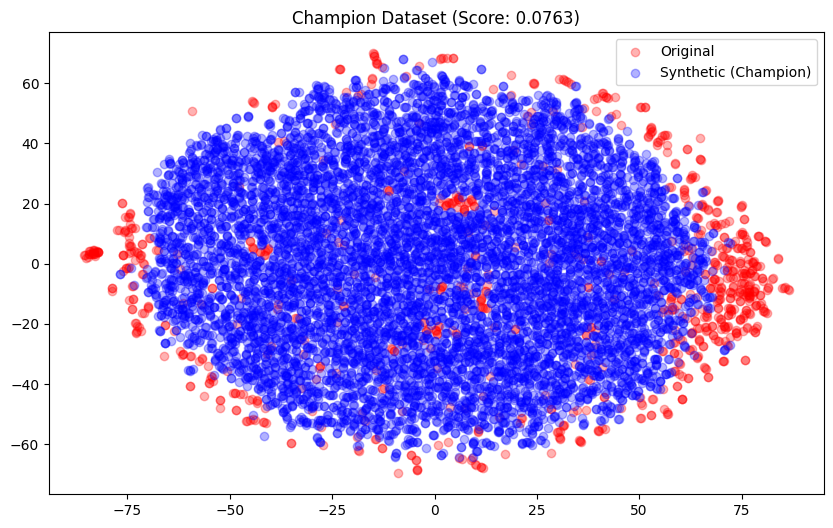

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- [Classes: Embedder, Recovery, Generator, Discriminator remain exactly as provided] ---
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, x):
        h, _ = self.rnn(x)
        return torch.sigmoid(self.fc(h))

class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        return self.fc(x_tilde)

class Generator(nn.Module):
    def __init__(self, noise_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(noise_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, z):
        h_hat, _ = self.rnn(z)
        return torch.sigmoid(self.fc(h_hat))

class Discriminator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, h):
        y_hat, _ = self.rnn(h)
        return self.fc(y_hat)

def preprocess_banking_data(df, seq_len=24):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    df = df.sort_values(['prism_consumer_id', 'posted_date'])
    df['days_diff'] = df.groupby('prism_consumer_id')['posted_date'].diff().dt.days.fillna(0)
    le = LabelEncoder()
    df['cat_idx'] = le.fit_transform(df['category'])
    scaler = MinMaxScaler()
    cols_to_scale = ['cat_idx', 'amount', 'running_balance', 'days_diff']
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    sequences = []
    minority_ids = df[df['DQ_TARGET'] == 1]['prism_consumer_id'].unique()
    for user_id in minority_ids:
        user_data = df[df['prism_consumer_id'] == user_id][cols_to_scale].values
        if len(user_data) >= seq_len:
            sequences.append(user_data[-seq_len:])
        else:
            padding = np.zeros((seq_len - len(user_data), len(cols_to_scale)))
            sequences.append(np.vstack([padding, user_data]))
    return np.array(sequences), scaler, le

# --- Setup Data ---
seq_len = 20
minority_data, scaler, label_encoder = preprocess_banking_data(history_df, seq_len)
real_data_tensor = torch.FloatTensor(minority_data)
hidden_dim = 24
input_dim = real_data_tensor.shape[2]

# --- Initialize Models & Optimizers ---
embedder = Embedder(input_dim, hidden_dim)
recovery = Recovery(hidden_dim, input_dim)
generator = Generator(hidden_dim, hidden_dim)
discriminator = Discriminator(hidden_dim)

opt_er = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()))
opt_g = torch.optim.Adam(generator.parameters())
opt_d = torch.optim.Adam(discriminator.parameters())

# --- TRAINING LOOP (Run once) ---
print("Training GAN Model...")
# Pre-training Embedder/Recovery
for epoch in range(100):
    opt_er.zero_grad()
    h = embedder(real_data_tensor)
    x_tilde = recovery(h)
    loss_r = torch.mean((real_data_tensor - x_tilde)**2)
    loss_r.backward()
    opt_er.step()

# Pre-training Generator
for epoch in range(100):
    opt_g.zero_grad()
    h_real = embedder(real_data_tensor).detach()
    h_hat_super = generator(h_real[:, :-1, :])
    loss_s = torch.mean((h_hat_super - h_real[:, 1:, :])**2)
    loss_s.backward()
    opt_g.step()

# Joint Training
eta_weight = 10 
lambda_weight = 1 
for epoch in range(400):
    z = torch.randn(real_data_tensor.shape[0], seq_len, hidden_dim)
    opt_g.zero_grad()
    h_fake = generator(z)
    d_fake = discriminator(h_fake)
    loss_u = -torch.mean(torch.log(torch.sigmoid(d_fake) + 1e-8))
    
    h_real = embedder(real_data_tensor).detach()
    h_hat_super = generator(h_real[:, :-1, :])
    loss_s = torch.mean((h_hat_super - h_real[:, 1:, :])**2)
    
    x_hat = recovery(h_fake)
    loss_v = torch.mean(torch.abs(torch.std(x_hat, dim=0) - torch.std(real_data_tensor, dim=0)))
    
    loss_g = loss_u + eta_weight * torch.sqrt(loss_s) + lambda_weight * loss_v
    loss_g.backward()
    opt_g.step()

    opt_d.zero_grad()
    d_real = discriminator(h_real)
    d_fake_det = discriminator(h_fake.detach())
    loss_d = -torch.mean(torch.log(torch.sigmoid(d_real) + 1e-8) + 
                         torch.log(1. - torch.sigmoid(d_fake_det) + 1e-8))
    if loss_d > 0.15:
        loss_d.backward()
        opt_d.step()

# --- AUTOMATED "BEST BATCH" SELECTION ---
print("\n--- Starting Champion Selection ---")

num_majority = len(history_df[history_df['DQ_TARGET'] == 0]['prism_consumer_id'].unique())
num_minority = len(history_df[history_df['DQ_TARGET'] == 1]['prism_consumer_id'].unique())
gap = num_majority - num_minority

best_score = float('inf')
best_synthetic_data = None
num_trials = 10  # How many different datasets to generate and test

# Calculate Real Stats Once
real_mean = torch.mean(real_data_tensor, dim=(0, 1))
real_std = torch.std(real_data_tensor, dim=(0, 1))

for trial in range(num_trials):
    # 1. Generate a new candidate batch
    z = torch.randn(gap, seq_len, hidden_dim)
    with torch.no_grad():
        synthetic_h = generator(z)
        candidate_data = recovery(synthetic_h) # Keep as tensor for fast scoring
    
    # 2. Score the batch (Lower score is better)
    # We compare the Mean and Std Dev of the candidate vs Real data across all features
    cand_mean = torch.mean(candidate_data, dim=(0, 1))
    cand_std = torch.std(candidate_data, dim=(0, 1))
    
    score_mean = torch.mean(torch.abs(cand_mean - real_mean))
    score_std = torch.mean(torch.abs(cand_std - real_std))
    
    total_score = score_mean + score_std
    
    print(f"Trial {trial+1}/{num_trials}: Score {total_score.item():.4f} (Mean Diff: {score_mean:.4f}, Std Diff: {score_std:.4f})")
    
    # 3. Keep the Champion
    if total_score < best_score:
        best_score = total_score
        best_synthetic_data = candidate_data.numpy() # Convert to numpy only when saving
        print(f"  -> New Champion found!")

print(f"\nWinner Selected with Score: {best_score:.4f}")

# --- Process the Champion Dataset ---
synthetic_data = best_synthetic_data # Use the best one found

flat_synthetic = synthetic_data.reshape(-1, input_dim)
unscaled_data = scaler.inverse_transform(flat_synthetic)
synthetic_df = pd.DataFrame(unscaled_data, columns=['cat_idx', 'amount', 'running_balance', 'days_diff'])
synthetic_df['category'] = label_encoder.inverse_transform(synthetic_df['cat_idx'].round().clip(0, len(label_encoder.classes_)-1).astype(int))
synthetic_df['days_diff'] = synthetic_df['days_diff'].clip(lower=0)
synthetic_df['posted_date'] = pd.Timestamp('2021-01-01') + pd.to_timedelta(synthetic_df.groupby(np.arange(len(synthetic_df)) // seq_len)['days_diff'].cumsum(), unit='D')
cat_type_map = history_df.drop_duplicates('category').set_index('category')['credit_or_debit'].to_dict()
synthetic_df['credit_or_debit'] = synthetic_df['category'].map(cat_type_map)
synthetic_df['signed_amount'] = np.where(synthetic_df['credit_or_debit'] == 'DEBIT', -synthetic_df['amount'], synthetic_df['amount'])
history_df['prism_consumer_id'] = history_df['prism_consumer_id'].astype(int)
start_id = history_df['prism_consumer_id'].max() + 1
unique_ids = np.arange(start_id, start_id + gap)
synthetic_df['prism_consumer_id'] = np.repeat(unique_ids, seq_len)
synthetic_df['DQ_TARGET'] = 1.0

# --- T-SNE Validation of the Winner ---
print("Generating t-SNE for the Champion Dataset...")
real_flat = real_data_tensor.numpy().reshape(real_data_tensor.shape[0], -1)
synth_flat = synthetic_data.reshape(synthetic_data.shape[0], -1)
combined_data = np.concatenate([real_flat, synth_flat], axis=0)
labels = np.array([0] * len(real_flat) + [1] * len(synth_flat))
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(combined_data)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_results[labels==0, 0], tsne_results[labels==0, 1], c='red', alpha=0.3, label='Original')
plt.scatter(tsne_results[labels==1, 0], tsne_results[labels==1, 1], c='blue', alpha=0.3, label='Synthetic (Champion)')
plt.title(f'Champion Dataset (Score: {best_score:.4f})')
plt.legend()
plt.show()